In [151]:
import pandas as pd

# base models
from sklearn.linear_model import LogisticRegression, LinearRegression

# final models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.neighbors import KNeighborsClassifier

import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score # metrics for imbalanced data
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, PolynomialFeatures
from sklearn.preprocessing import TargetEncoder # this one doesn't result in leakage
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import StackingClassifier

from tqdm.auto import tqdm

In [152]:
pd.read_csv("data/midterm/midterm_data_dictionary.csv")

,column_name,description,type
0,id,Internal record identifier for each observation.,identifier
1,customer_age,Age of the customer when the outreach event oc...,numeric
2,occupation_type,Work category associated with the customer.,categorical
3,relationship_status,Current household or partnership status.,categorical
4,education_background,Reported educational attainment category.,categorical
5,has_credit_issue,Indicator of prior credit repayment problems o...,categorical/binary
6,mortgage_status,Indicator showing whether the customer has a h...,categorical/binary
7,personal_loan_status,Indicator showing whether the customer has a p...,categorical/binary
8,last_contact_month,Calendar month of the most recent outreach att...,categorical
9,day_of_week,Weekday on which the most recent contact took ...,categorical


In [153]:
train_df = pd.read_csv("data/midterm/midterm_train.csv", index_col="id")
train_df.head()

,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
id,,,,,,,,,,,,,,,,,,,,,
12556,28,services,married,high.school,no,yes,no,jul,tue,286,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
17914,43,admin.,single,university.degree,no,yes,no,aug,fri,213,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
3315,41,admin.,married,unknown,no,no,no,sep,wed,845,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


# Exploratory Data Analysis

In [154]:
# check distribution of target variable
train_df["accepted_offer"].value_counts() # SUPER imbalanced

accepted_offer
0    29235
1     3715
Name: count, dtype: int64

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)



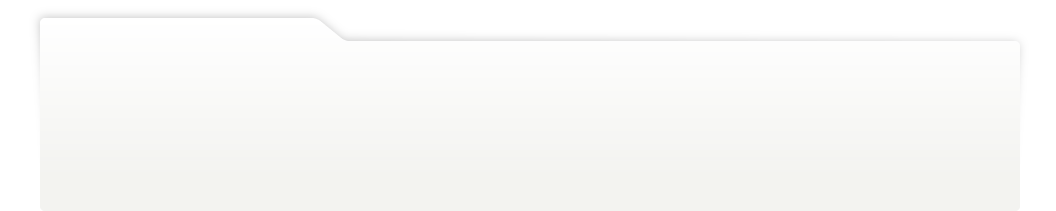
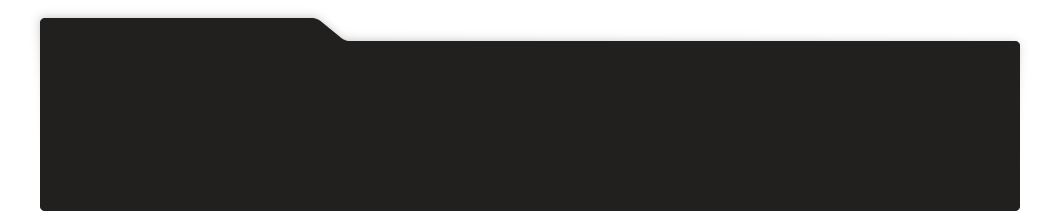
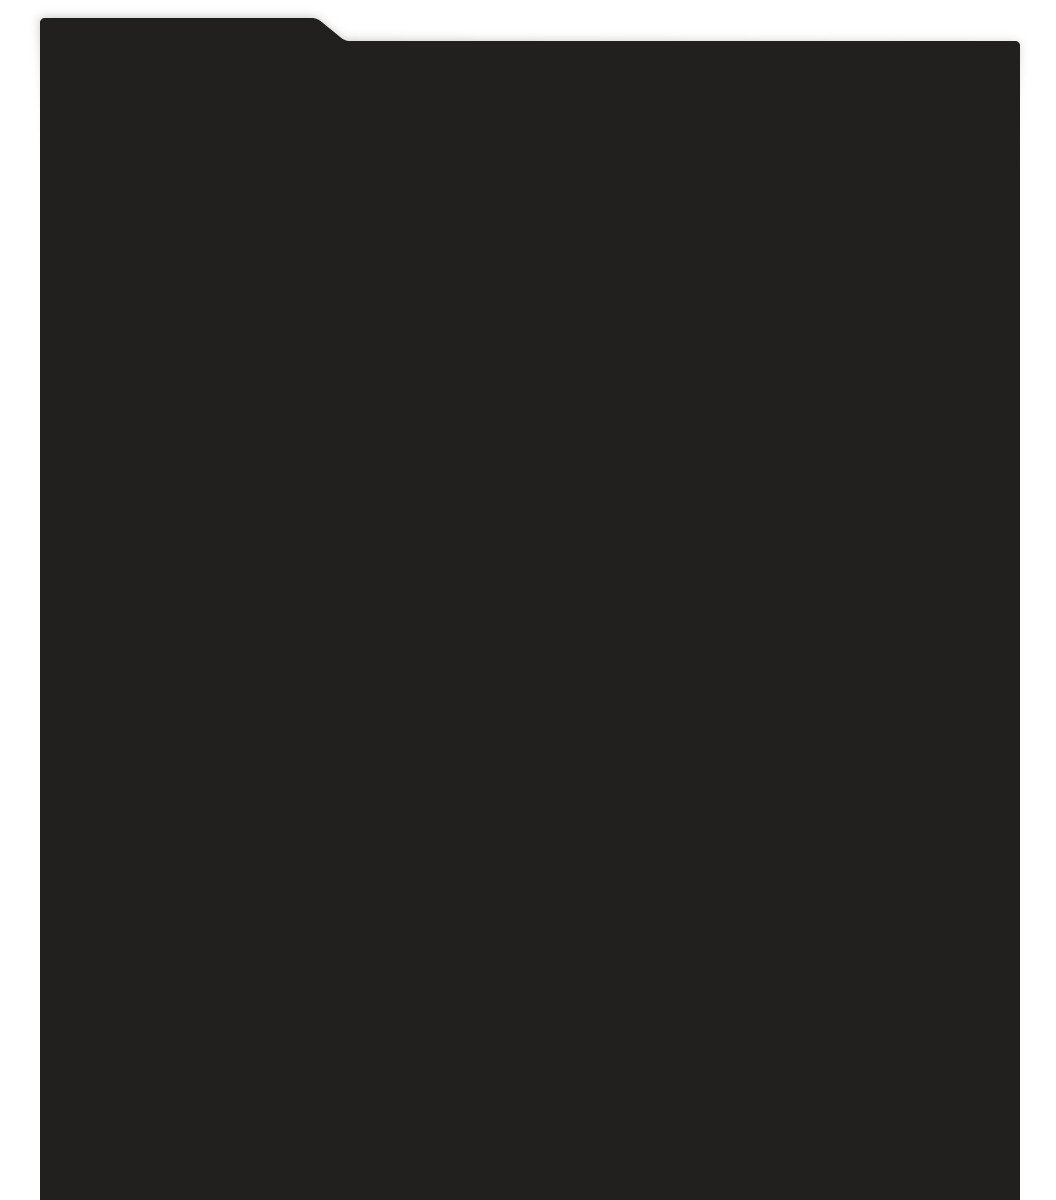
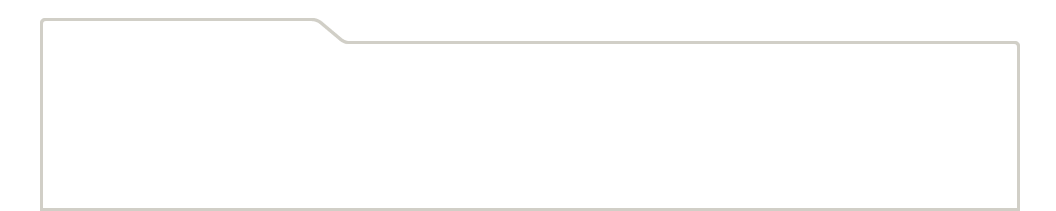
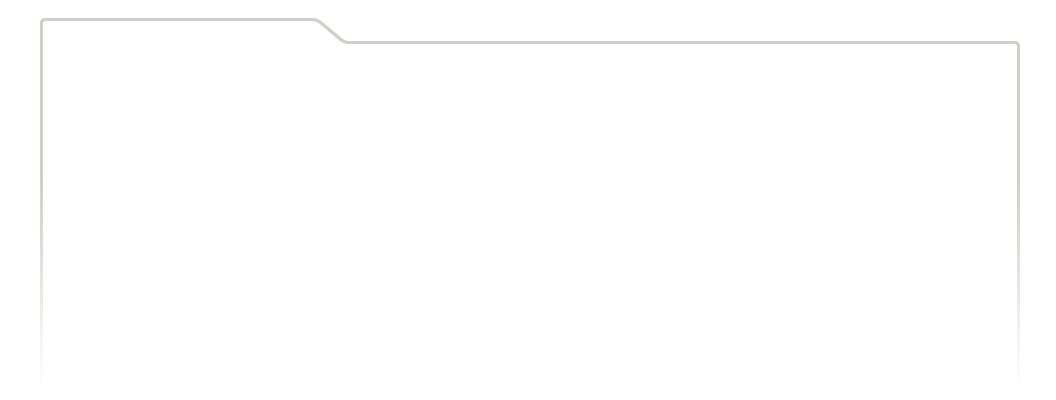
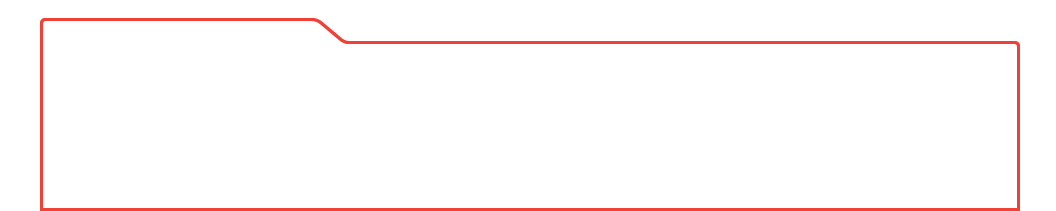
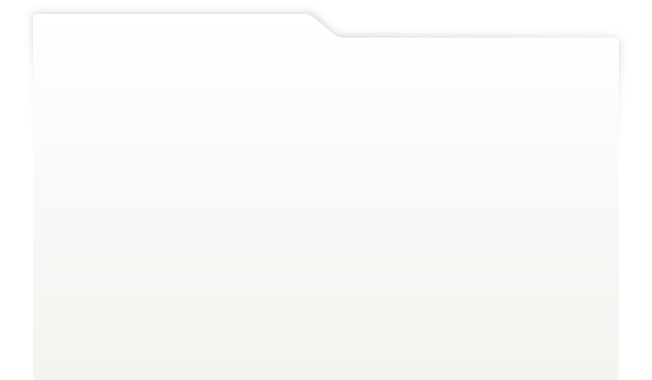
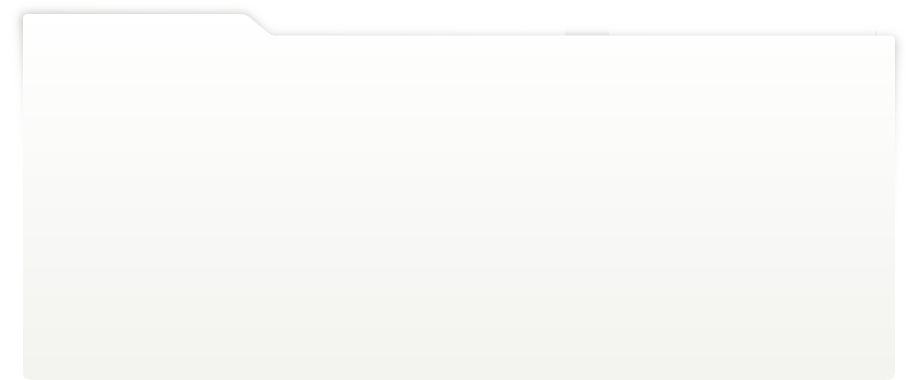
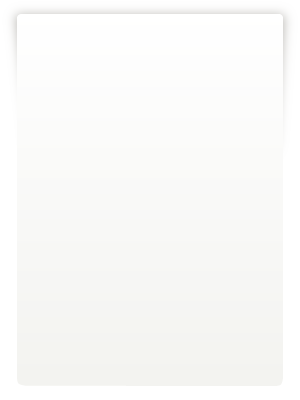
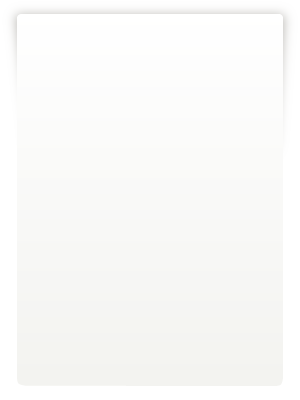
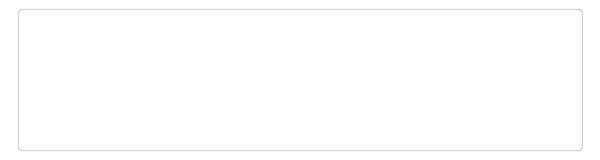
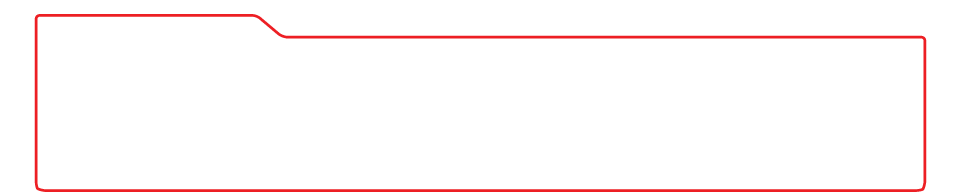
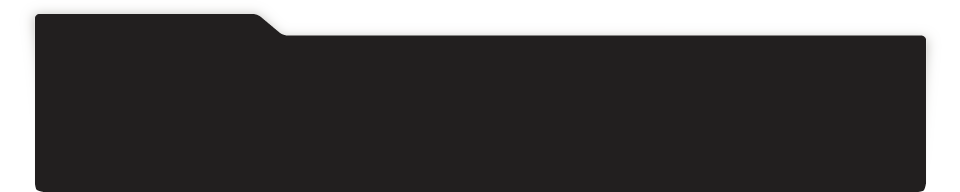
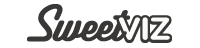
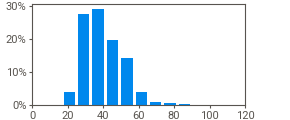
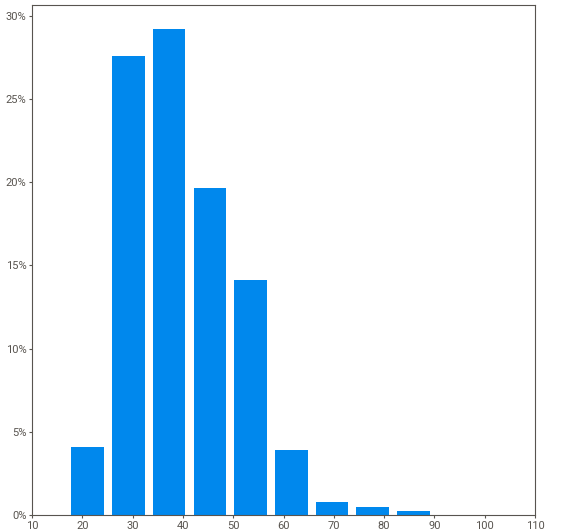
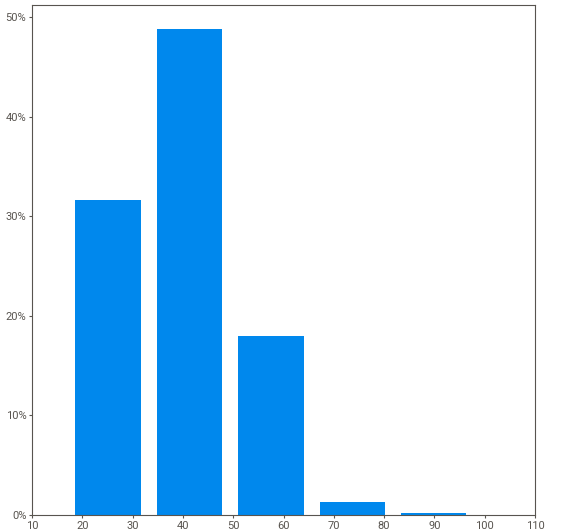
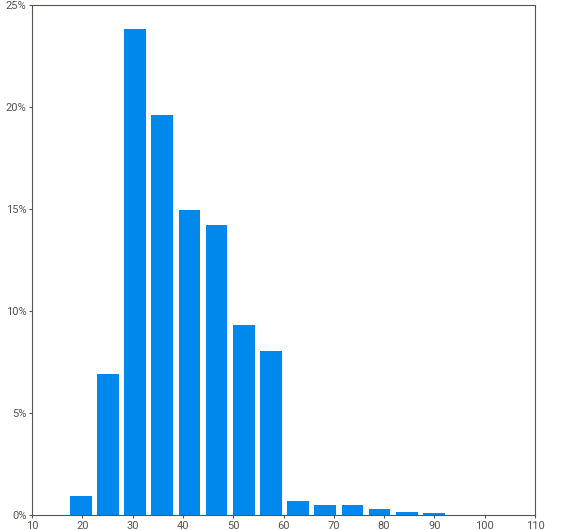
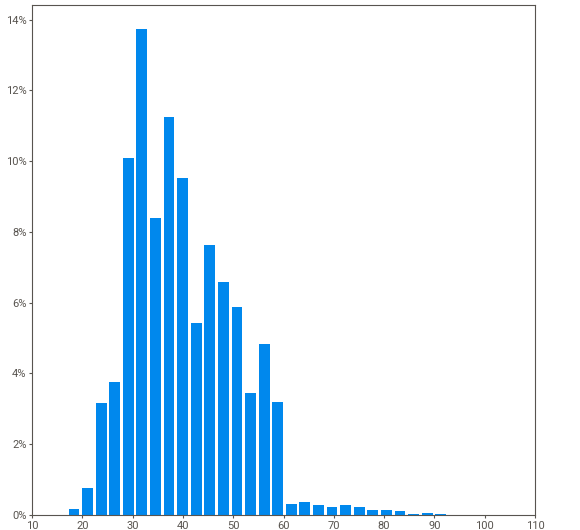
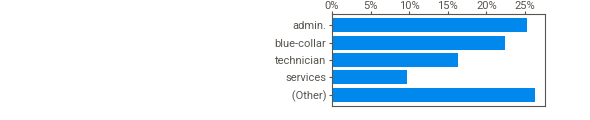
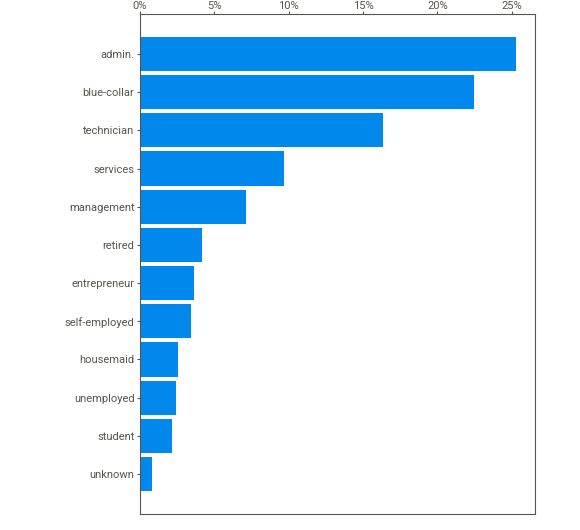
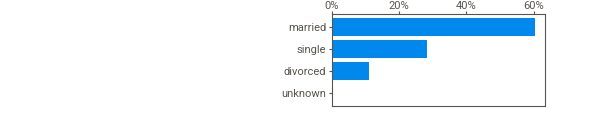
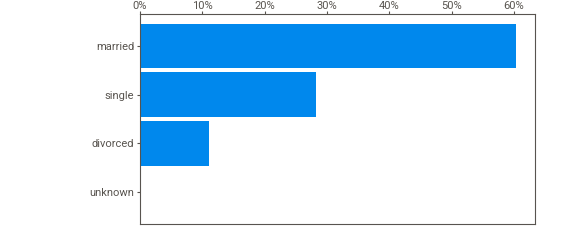
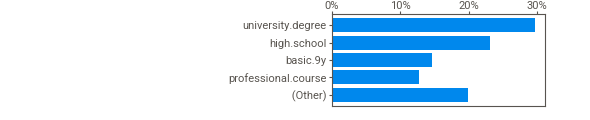
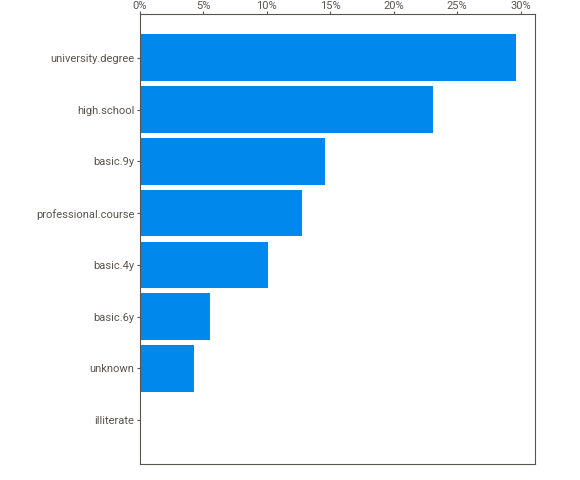
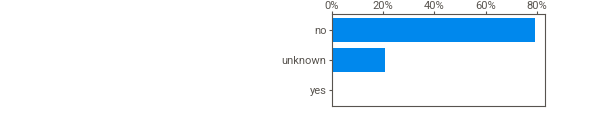
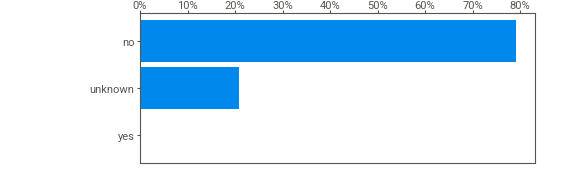
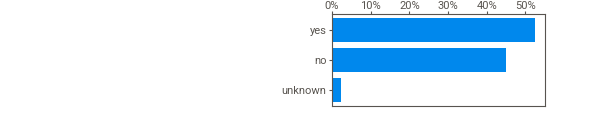
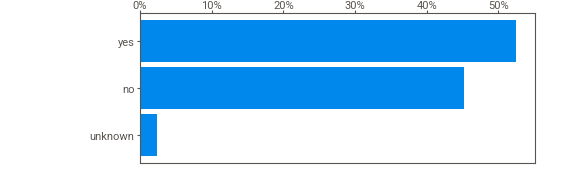
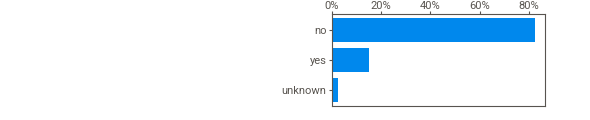
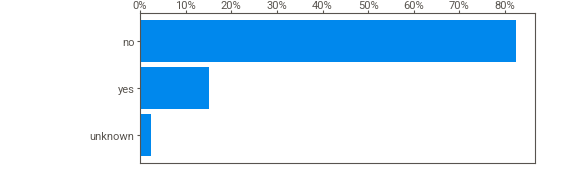
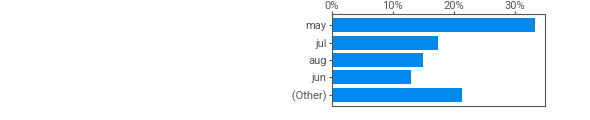
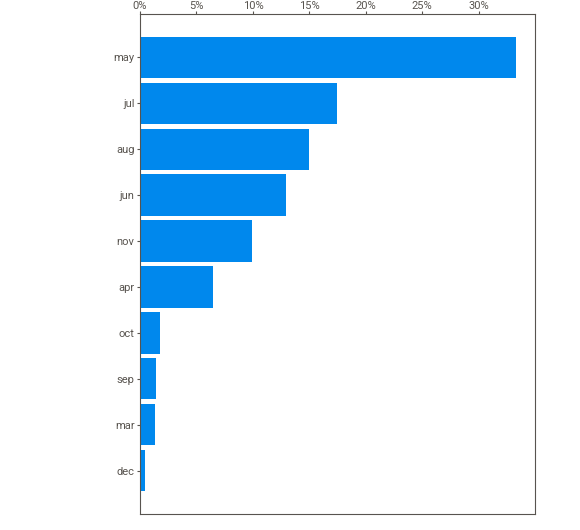
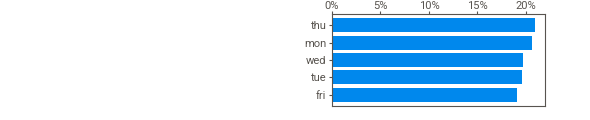
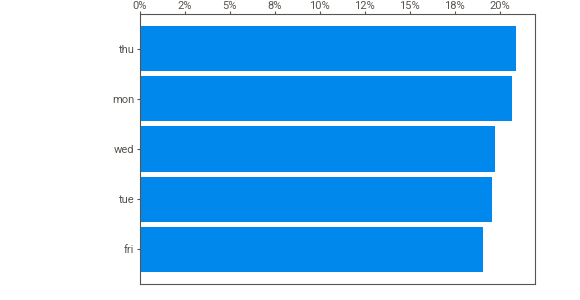
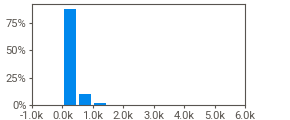
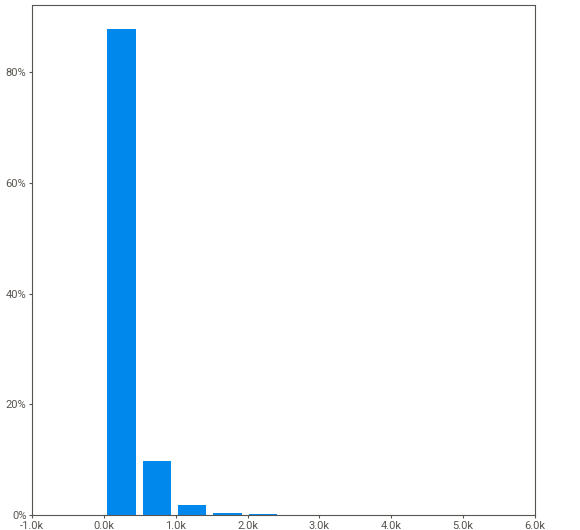
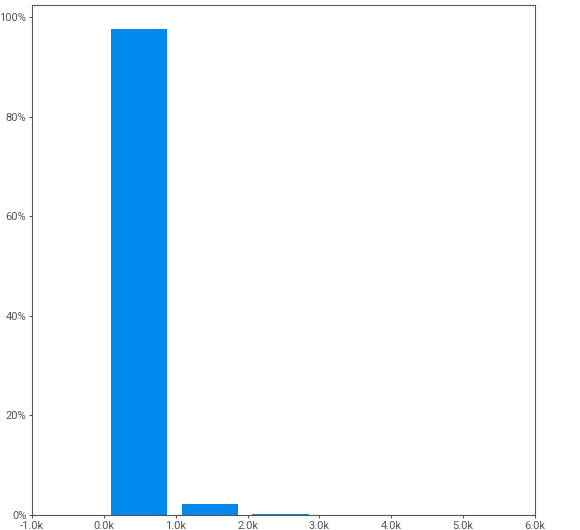
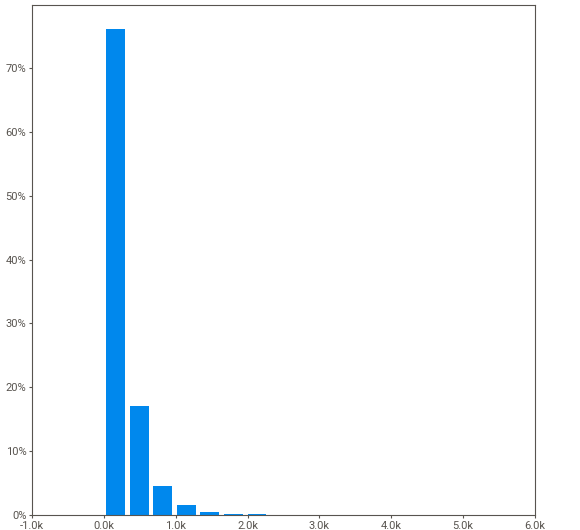
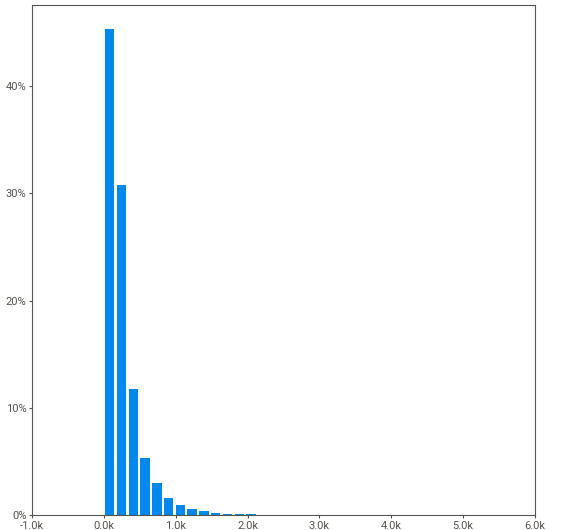
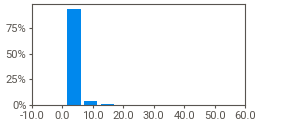
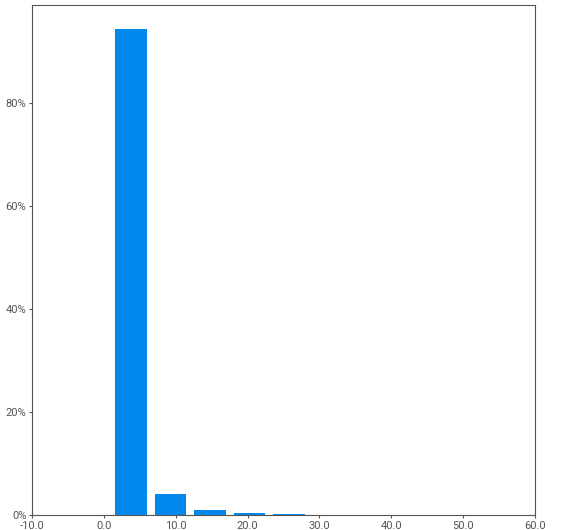
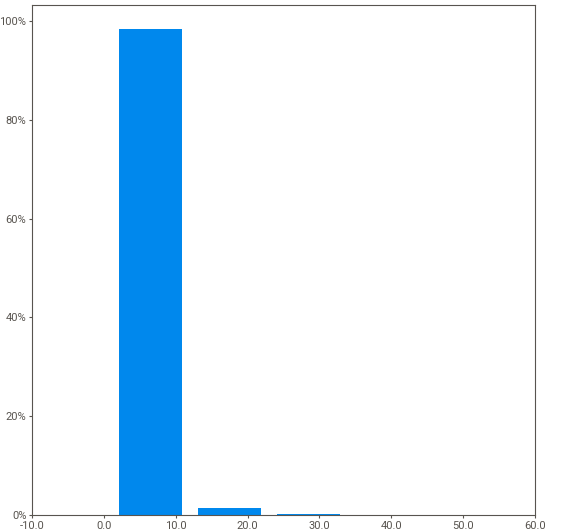
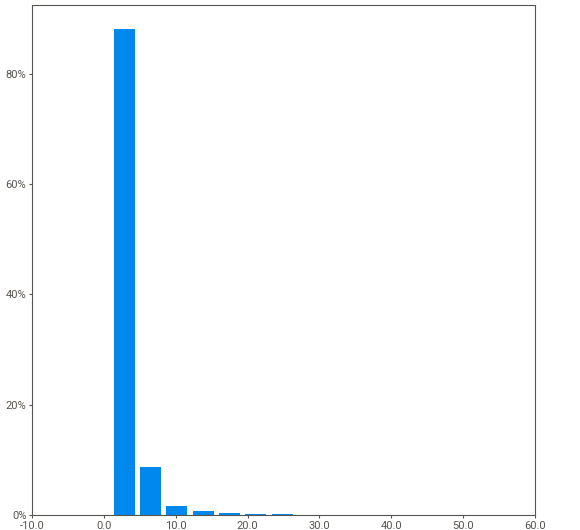
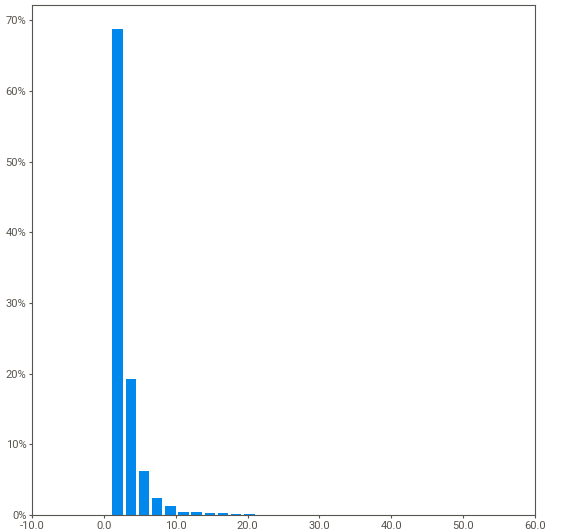
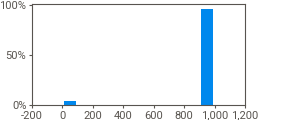
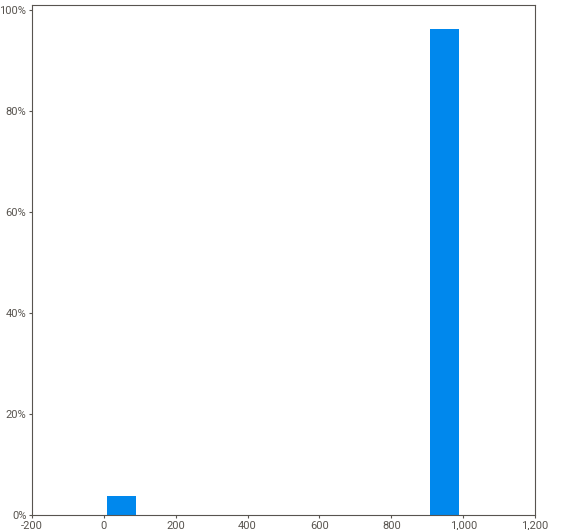
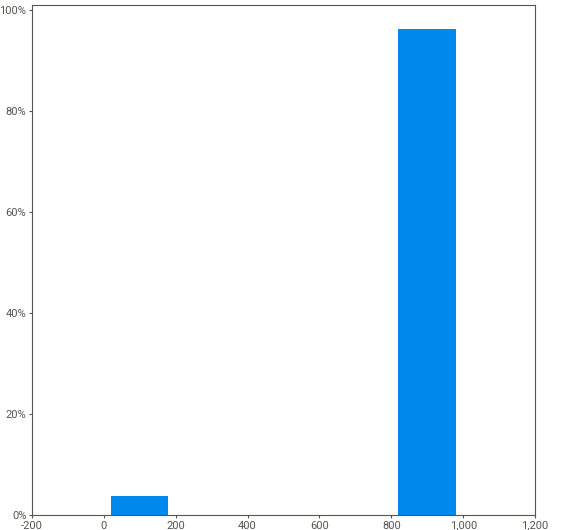
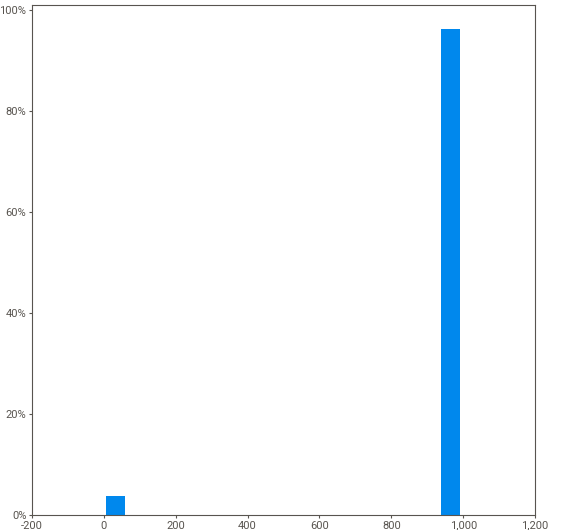
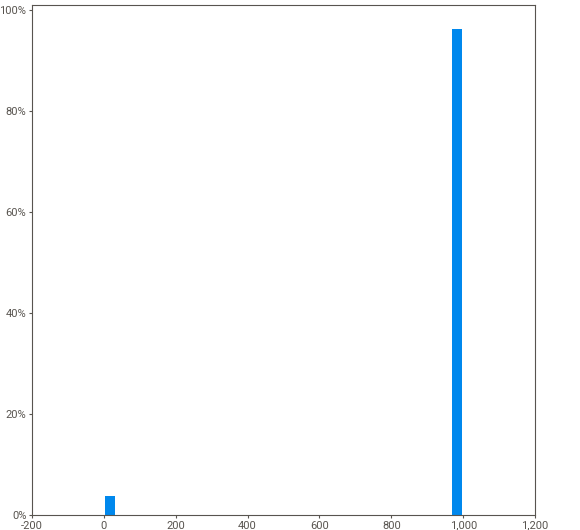
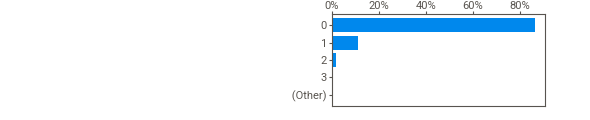
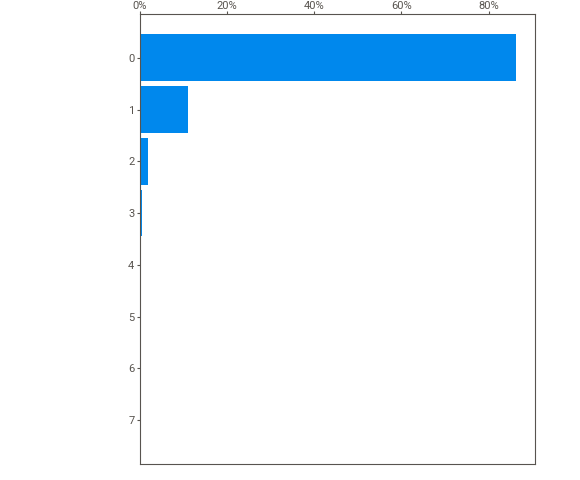
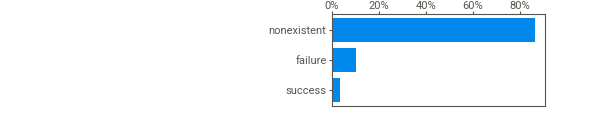
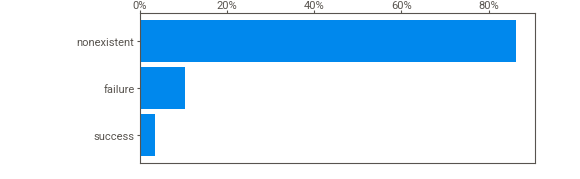
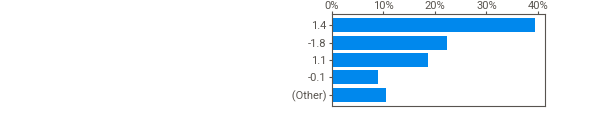
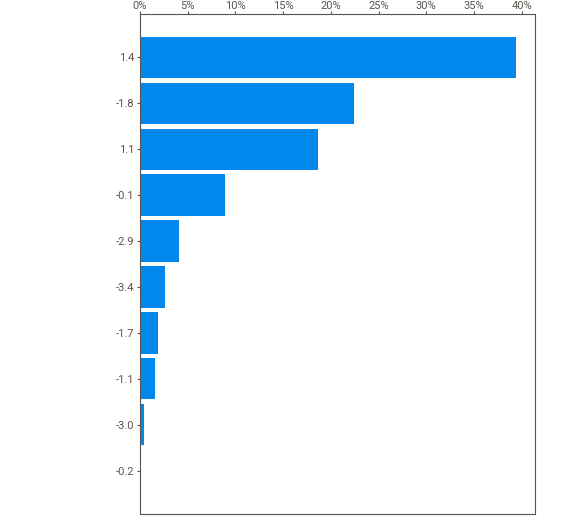
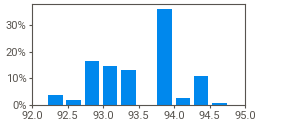
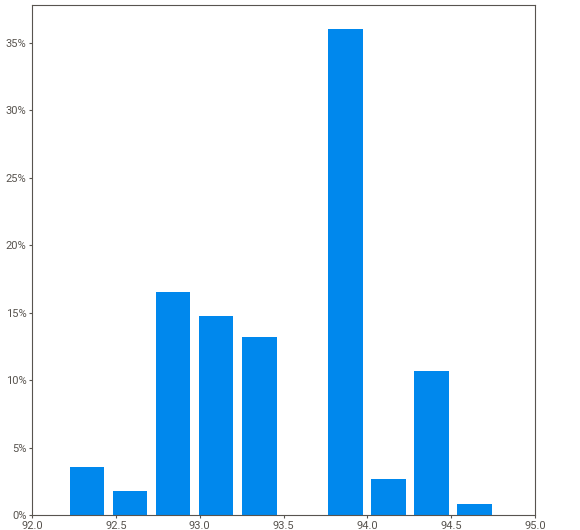
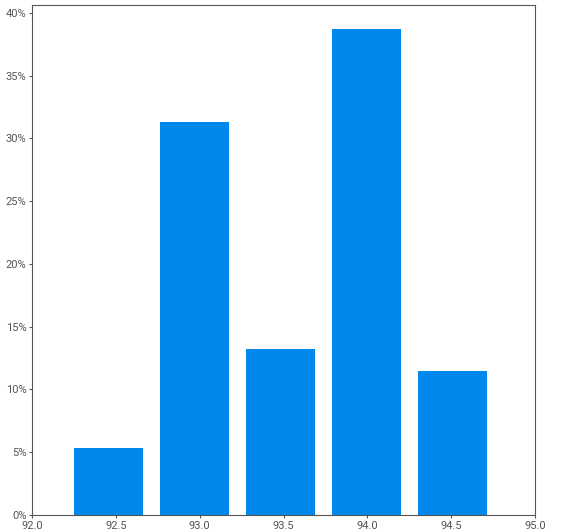
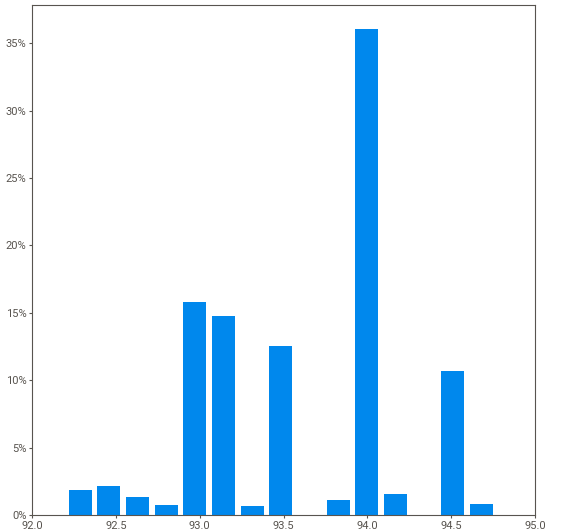
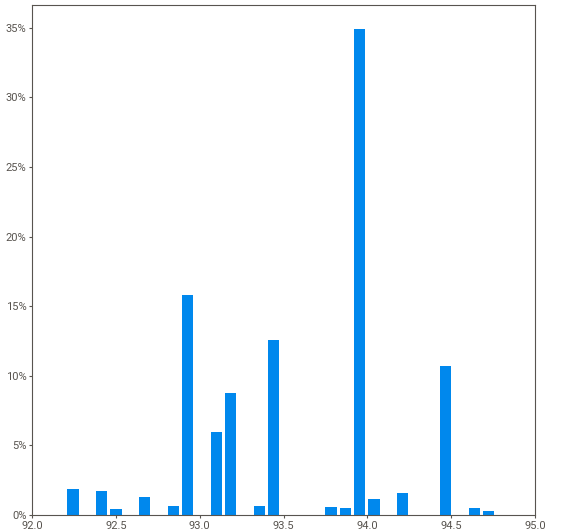
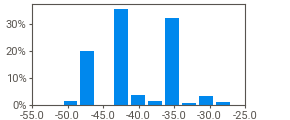
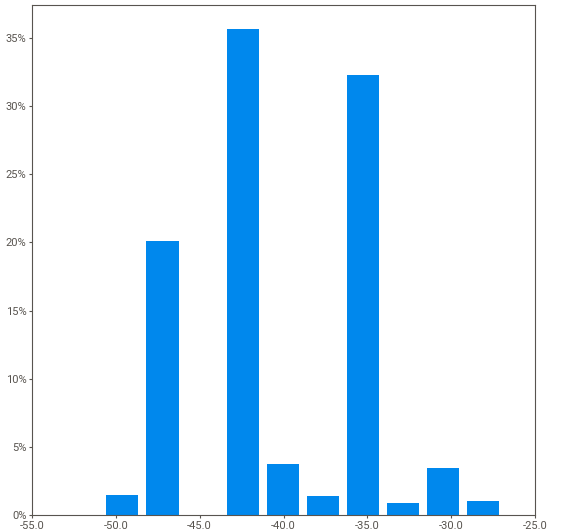
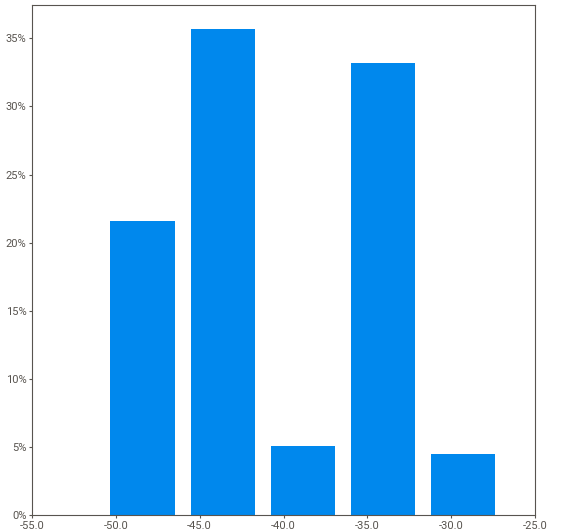
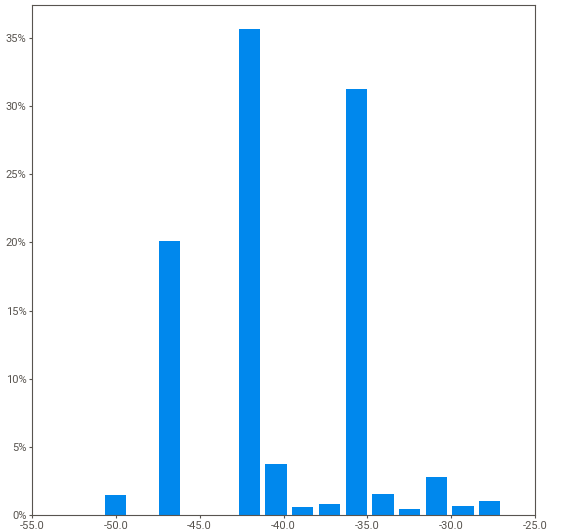
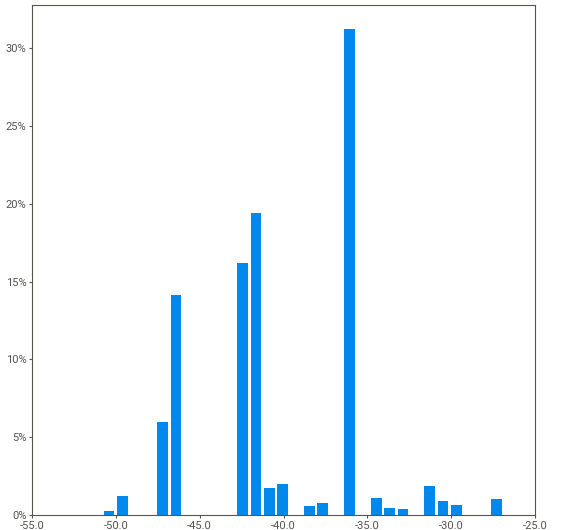
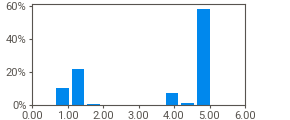
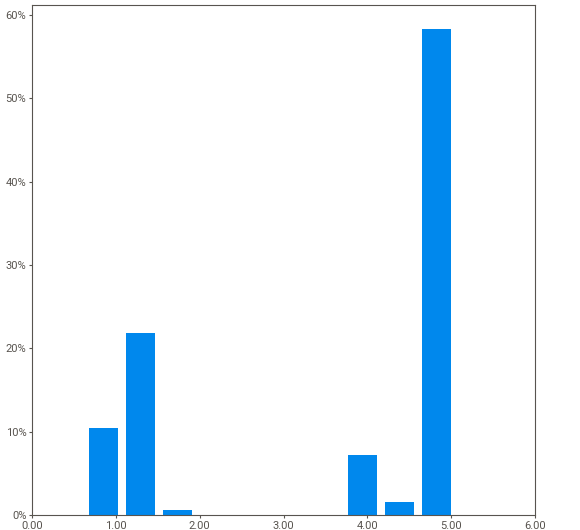
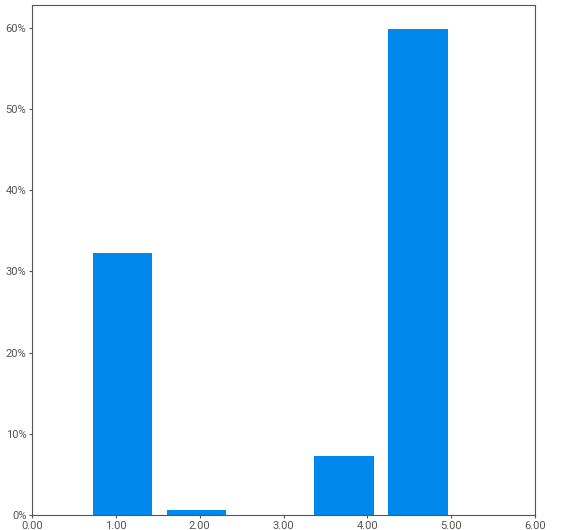
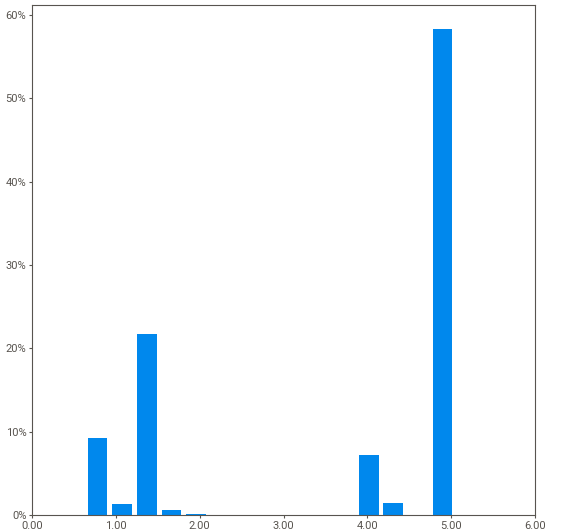
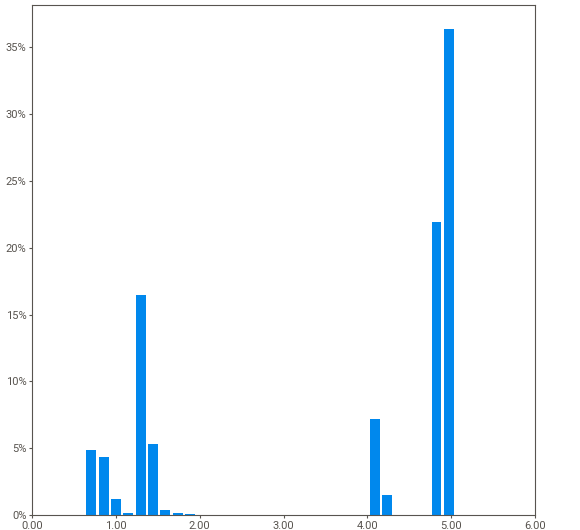
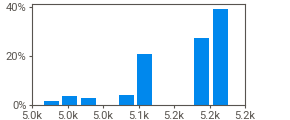
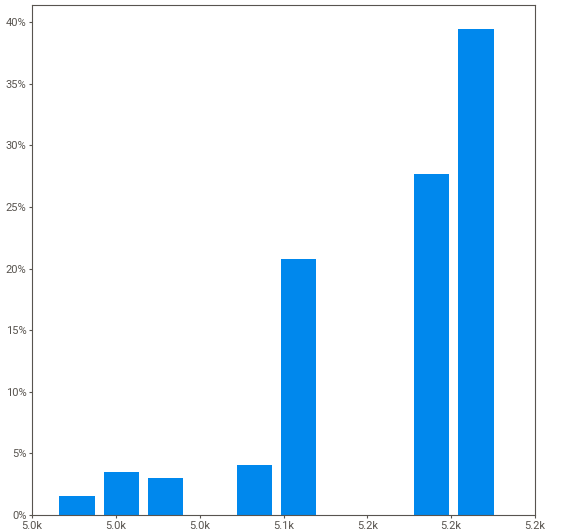
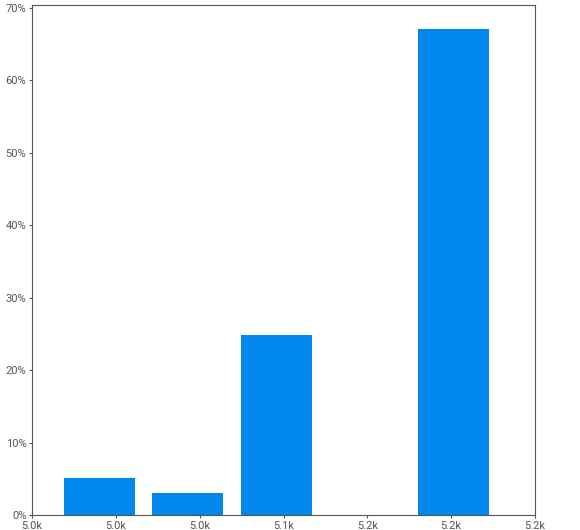
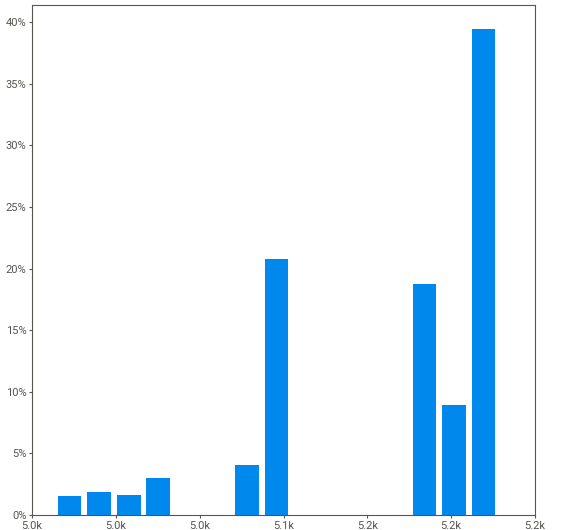
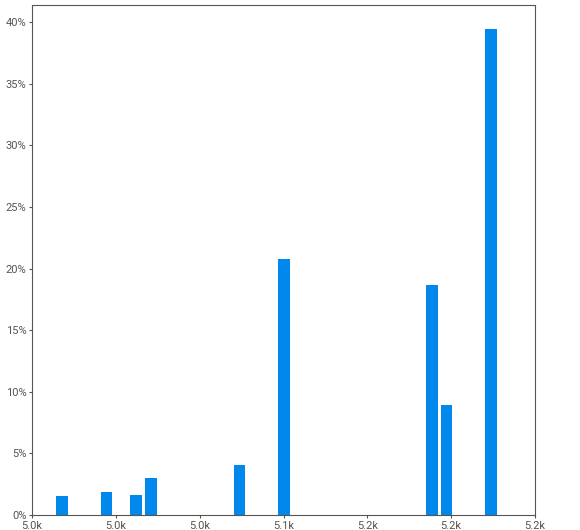
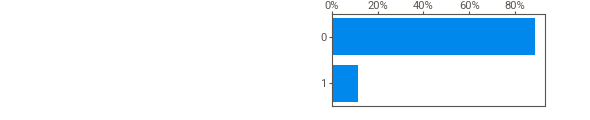
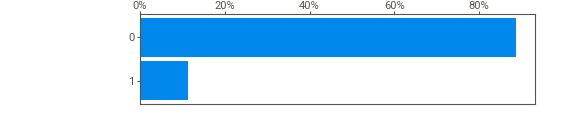
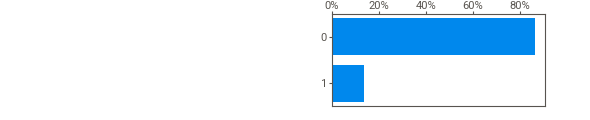
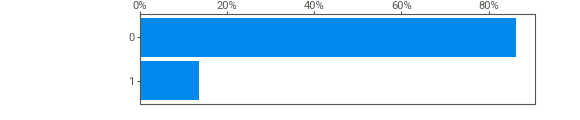
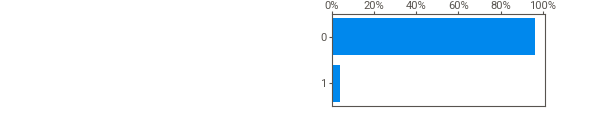
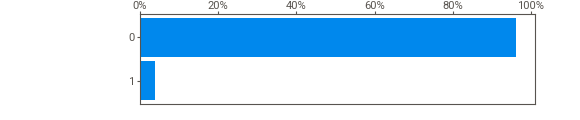
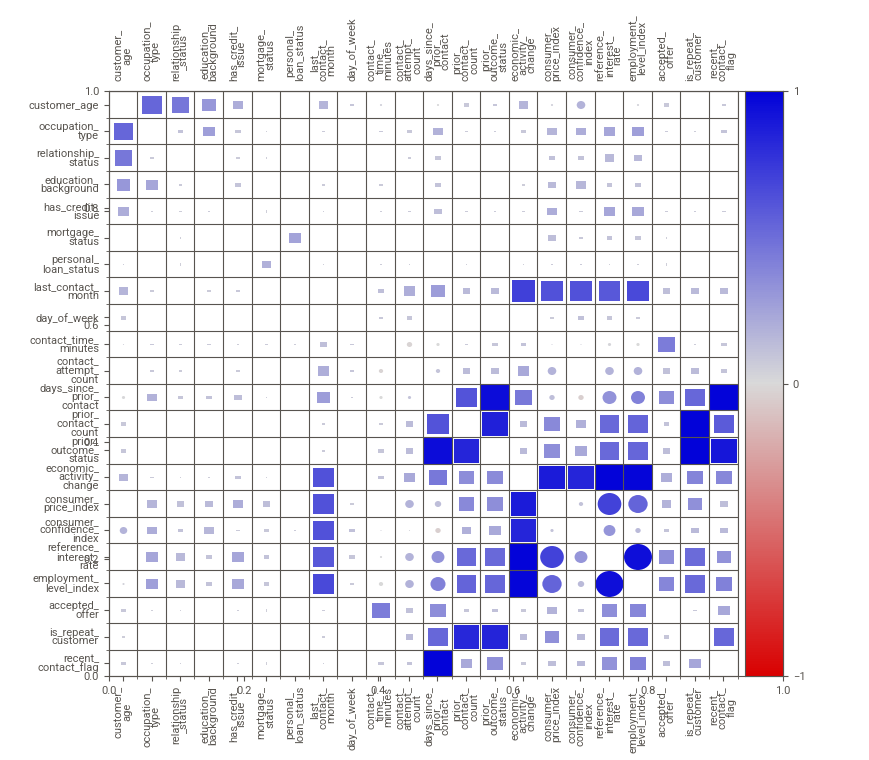
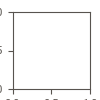

In [155]:
import sweetviz as sv

report = sv.analyze(train_df)
report.show_notebook()

# Data Preparation

In [156]:
# split data
X = train_df.drop(columns=["accepted_offer"])
y = train_df["accepted_offer"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# maintain same splits across for each training
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Feature Engineering

- feature engineering improves the models. in general, the best technique was to simply target encode then scale. encoding and then yeo-johnson-ing seems to be nearly as good.
- compared to a simple one-hot encoding scheme, we see a 1.5% boost in `balanced_accuracy`
- because we aren't in a performance-sensitive environment, rather than selecting individual features, we will use the feature set that each model performed best with.

In [157]:
# get cols by data-type
cat_selector = make_column_selector(dtype_include=["str", "object", "category"])
num_selector = make_column_selector(dtype_include=["number"])

In [158]:
# target encode transformer and some mutations
# TargetEncoder() MUST be used in a Pipeline() or it will result in leakage.
ct_ohe = ColumnTransformer([
    ("ohe", OneHotEncoder(sparse_output=False), cat_selector)
], remainder="passthrough").set_output(transform="pandas")

ct_encode = ColumnTransformer([
    ("target_encode", TargetEncoder(target_type="binary"), cat_selector)
], remainder="passthrough").set_output(transform="pandas")

ct_encode_scale = ColumnTransformer([
    ("target_encode", TargetEncoder(target_type="binary"), cat_selector),
    ("scale", StandardScaler(), num_selector),
], remainder="passthrough").set_output(transform="pandas")

ct_encode_scale_poly = ColumnTransformer([
    ("target_encode", TargetEncoder(target_type="binary"), cat_selector),
    ("scale", StandardScaler(), num_selector),
    ("poly", PolynomialFeatures(degree=3, interaction_only=True), num_selector)
], remainder="passthrough").set_output(transform="pandas")

ct_encode_yeo = ColumnTransformer([
    ("target_encode", TargetEncoder(target_type="binary"), cat_selector),
    ("yeo", PowerTransformer(), num_selector)
], remainder="passthrough").set_output(transform="pandas")

ct_encode_yeo_poly = ColumnTransformer([
    ("target_encode", TargetEncoder(target_type="binary"), cat_selector),
    ("yeo", PowerTransformer(), num_selector),
    ("poly", PolynomialFeatures(degree=3, interaction_only=True), num_selector)
], remainder="passthrough").set_output(transform="pandas")

transformers = [
    ("ohe", ct_ohe),
    ("encode", ct_encode),
    ("encode_scale", ct_encode_scale),
    ("encode_scale_poly", ct_encode_scale_poly),
    ("encode_yeo", ct_encode_yeo),
    ("encode_yeo_poly",ct_encode_yeo_poly)
]

# Modeling and Evaluation

In [162]:
# set up each base model's specs

# boosted-trees
lgbm = LGBMClassifier(random_state=42, verbose=0)
xgb = XGBClassifier(random_state=42, device="cuda:0", tree_method="hist",)

# cluster. expected to break on non-scaled data
knn = KNeighborsClassifier(n_jobs=-1)

# weird
gnb = GaussianNB()

# linear-ish. expected to break on non-scaled data
logistic = LogisticRegression(random_state=42, max_iter=5_000)
svc = SVC(random_state=42, kernel="rbf", max_iter=5_000)

models = [
    ("gnb", gnb),
    ("xgb", xgb),
    ("knn", knn),
    ("lgbm", lgbm),
    ("logistic", logistic),
    ("svc", svc),
]

In [163]:
def train_and_evaluate_model(model_name, model, transformer_name, transformer):
    # use the given preprocessing transformer
    pipe = Pipeline([
        ("ct", transformer),
        ("model", model)
    ])

    # get cv scores
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=skf, n_jobs=-1, scoring="balanced_accuracy")

    # fit on full training data
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    # get a final score
    score = balanced_accuracy_score(y_test, preds)

    return {
        "model": model_name,
        "transformer": transformer_name,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "score": score,
        "pipe": pipe
    }

In [164]:
# train the models and compile the results
training_results = []
combos = [(m, t) for m in models for t in transformers]

for (model_name, model), (transformer_name, transformer) in tqdm(combos, desc="Training"):
    res = train_and_evaluate_model(model_name, model, transformer_name, transformer)
    training_results.append(res)

training_results = pd.DataFrame(training_results).sort_values("score", ascending=False)
training_results

Training:  58%|█████▊    | 21/36 [00:40<00:22,  1.49s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines


Training:  64%|██████▍   | 23/36 [00:45<00:26,  2.04s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines


Training:  67%|██████▋   | 24/36 [00:50<00:35,  2.99s/it]C:\miniforge3\envs\machine-learning\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Training:  69%|██████▉   | 25/36 [01:30<02:33, 13.97s/it]C:\miniforge3\envs\machine-learning\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_

,model,transformer,cv_mean,cv_std,score,pipe
10,xgb,encode_yeo,0.767009,0.011072,0.775876,"(ColumnTransformer(remainder='passthrough',\n ..."
23,lgbm,encode_yeo_poly,0.754411,0.010363,0.774866,"(ColumnTransformer(remainder='passthrough',\n ..."
20,lgbm,encode_scale,0.760609,0.010586,0.773589,"(ColumnTransformer(remainder='passthrough',\n ..."
7,xgb,encode,0.754379,0.015831,0.772389,"(ColumnTransformer(remainder='passthrough',\n ..."
8,xgb,encode_scale,0.759741,0.011954,0.772044,"(ColumnTransformer(remainder='passthrough',\n ..."
11,xgb,encode_yeo_poly,0.756688,0.011915,0.769078,"(ColumnTransformer(remainder='passthrough',\n ..."
3,gnb,encode_scale_poly,0.761706,0.010255,0.768863,"(ColumnTransformer(remainder='passthrough',\n ..."
5,gnb,encode_yeo_poly,0.761706,0.010255,0.768863,"(ColumnTransformer(remainder='passthrough',\n ..."
18,lgbm,ohe,0.755767,0.006779,0.767825,"(ColumnTransformer(remainder='passthrough',\n ..."
22,lgbm,encode_yeo,0.755847,0.013029,0.764847,"(ColumnTransformer(remainder='passthrough',\n ..."


In [165]:
# which feature sets did the models generally like best?
training_results \
    .groupby("transformer")[["cv_mean"]] \
    .agg(mean=("cv_mean", "mean"), std=("cv_mean", "std")) \
    .sort_values("mean", ascending=False)

,mean,std
transformer,,
encode_scale,0.718581,0.036497
encode_scale_poly,0.717607,0.045725
encode_yeo_poly,0.717105,0.045435
encode_yeo,0.711685,0.042439
encode,0.702415,0.059567
ohe,0.701612,0.057812


In [166]:
# we will tune and stack these models
best_three_models = training_results.loc[
    training_results.groupby("model")["cv_mean"].idxmax()
][["model", "transformer", "cv_mean", "score", "pipe"]].sort_values("cv_mean", ascending=False).head(3)[["model", "transformer", "cv_mean", "pipe"]]

best_three_models

,model,transformer,cv_mean,pipe
10,xgb,encode_yeo,0.767009,"(ColumnTransformer(remainder='passthrough',\n ..."
3,gnb,encode_scale_poly,0.761706,"(ColumnTransformer(remainder='passthrough',\n ..."
20,lgbm,encode_scale,0.760609,"(ColumnTransformer(remainder='passthrough',\n ..."


## Tuning

In [167]:
def objective_gnb(trial):
    var_smoothing = trial.suggest_float("var_smoothing", 1e-10, 1e-1, log=True)

    pipe = Pipeline([
        ("preprocessor", ct_encode_scale_poly),
        ("model", GaussianNB(var_smoothing=var_smoothing))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=skf,
                             scoring="balanced_accuracy", n_jobs=-1)
    return scores.mean()

In [168]:
def objective_xgb(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "eval_metric": "auc",
        "use_label_encoder": False,
        "random_state": 42,
    }

    pipe = Pipeline([
        ("preprocessor", ct_encode_yeo),
        ("model", XGBClassifier(**params))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=skf,
                             scoring="balanced_accuracy", n_jobs=-1)
    return scores.mean()

In [169]:
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "verbose": -1,
    }

    pipe = Pipeline([
        ("preprocessor", ct_encode),
        ("model", LGBMClassifier(**params))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=skf,
                             scoring="balanced_accuracy", n_jobs=-1)
    return scores.mean()

In [170]:
# run the finetuning
sampler = optuna.samplers.TPESampler(seed=42)

study_gnb  = optuna.create_study(direction="maximize", sampler=sampler, study_name="gnb")
study_xgb  = optuna.create_study(direction="maximize", sampler=sampler, study_name="xgb")
study_lgbm = optuna.create_study(direction="maximize", sampler=sampler, study_name="lgbm")

study_gnb.optimize(objective_gnb,   n_trials=100)
study_xgb.optimize(objective_xgb,   n_trials=100)
study_lgbm.optimize(objective_lgbm, n_trials=100)

print("GNB  best:", study_gnb.best_params,  "→", study_gnb.best_value)
print("XGB  best:", study_xgb.best_params,  "→", study_xgb.best_value)
print("LGBM best:", study_lgbm.best_params, "→", study_lgbm.best_value)

[I 2026-05-07 20:29:11,306] A new study created in memory with name: gnb
[I 2026-05-07 20:29:11,306] A new study created in memory with name: xgb
[I 2026-05-07 20:29:11,309] A new study created in memory with name: lgbm
[I 2026-05-07 20:29:11,814] Trial 0 finished with value: 0.7555207117855754 and parameters: {'var_smoothing': 2.348881295853311e-07}. Best is trial 0 with value: 0.7555207117855754.
[I 2026-05-07 20:29:12,317] Trial 1 finished with value: 0.6022674513031918 and parameters: {'var_smoothing': 0.03601046734447532}. Best is trial 0 with value: 0.7555207117855754.
[I 2026-05-07 20:29:12,809] Trial 2 finished with value: 0.7276531200763168 and parameters: {'var_smoothing': 0.00038720902953704107}. Best is trial 0 with value: 0.7555207117855754.
[I 2026-05-07 20:29:13,303] Trial 3 finished with value: 0.7417030452719514 and parameters: {'var_smoothing': 2.4430162614261403e-05}. Best is trial 0 with value: 0.7555207117855754.
[I 2026-05-07 20:29:13,800] Trial 4 finished with va

GNB  best: {'var_smoothing': 1.7873195544004214e-08} → 0.7668330962363108
XGB  best: {'n_estimators': 782, 'max_depth': 6, 'learning_rate': 0.046162860362005044, 'subsample': 0.7287986538853427, 'colsample_bytree': 0.7195376443884769, 'min_child_weight': 6, 'reg_alpha': 0.06555786470781022, 'reg_lambda': 0.0018269957878076944} → 0.7762025841010891
LGBM best: {'n_estimators': 181, 'max_depth': 10, 'learning_rate': 0.08359938684835579, 'num_leaves': 96, 'subsample': 0.5657700515609337, 'colsample_bytree': 0.9509685872882578, 'min_child_samples': 5, 'reg_alpha': 3.6767249978372325, 'reg_lambda': 0.019548815929559687} → 0.76816776018341


# Ensembling

In [176]:
# set up final "base" models
best_gnb = Pipeline([
    ("preprocessor", ct_encode_scale_poly),
    ("model", GaussianNB(**study_gnb.best_params))
])

best_xgb = Pipeline([
    ("preprocessor", ct_encode_yeo),
    ("model", XGBClassifier(
        **study_xgb.best_params,
        random_state=42,
        n_jobs=1,
        eval_metric="logloss",
    ))
])

best_lgbm = Pipeline([
    ("preprocessor", ct_encode),
    ("model", LGBMClassifier(
        **study_lgbm.best_params,
        random_state=42,
        n_jobs=1,
        verbose=-1,
    ))
])

In [178]:
# stack the models
estimators = [
    ("gnb",  best_gnb),
    ("xgb",  best_xgb),
    ("lgbm", best_lgbm),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    stack_method="predict_proba",
    cv=skf,
    n_jobs=-1,
    passthrough=False,
)

# evaluate the stack
stack_cv_scores = cross_val_score(
    stack, X_train, y_train,
    cv=skf, scoring="balanced_accuracy", n_jobs=-1
)
print(f"Balanced Accuracy CV Scores: {stack_cv_scores.mean():.4f} ± {stack_cv_scores.std():.4f}")

Balanced Accuracy CV Scores: 0.7291 ± 0.0051


# Results Summary

Overall, we evaluate 6 models across 6 feature sets and one stacked model comprised of the three best performing base models. This makes for a grand total of 37 models trained.

Of the first 36 models, the three best performers, according to their balanced accuracy, were

- `GaussianNB` (0.7617),
- `XGBoost` (0.7615)
- `LightGBM` (0.7579)

After finetuning and stacking via , the the model performance degraded with a score of (0.7350).

The table below shows the fine-tuned performance of the top three models and their stack.

| model   | feature set                               | balanced accuracy score |
|---------|-------------------------------------------|-------------------------|
| GNB     | target encode, scale, polynomial          | 0.7668                  |
| XGB     | target encode, yeo johnson                | 0.7817                  |
| LGBM    |  target encoding                          | 0.7673                  |
| StacK   | _each model gets its desired feature set_ | 0.7291                  |

**Selecting based on performance, our final model will be (as always) `XGBoost` with target encoded and yeo-johnson features.**


# Final Model & Predictions

In [179]:
# train the final model
best_xgb = Pipeline([
    ("preprocessor", ct_encode_yeo),
    ("model", XGBClassifier(
        **study_xgb.best_params,
        random_state=42,
        n_jobs=1,
        eval_metric="logloss",
    ))
])

best_xgb.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_encode', ...), ('yeo', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [180]:
test_df = pd.read_csv("data/midterm/midterm_test.csv", index_col="id")
test_df.head()

,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,...,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag
id,,,,,,,,,,,,,,,,,,,,,
32884,28,admin.,single,university.degree,no,yes,no,jun,fri,12,...,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0,0
3169,60,admin.,married,university.degree,no,no,no,apr,fri,246,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
32206,35,unemployed,married,university.degree,no,yes,no,oct,thu,391,...,999,0,nonexistent,-3.4,92.431,-26.9,0.733,5017.5,0,0
9403,54,housemaid,single,basic.9y,unknown,no,no,nov,mon,158,...,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1,0
14020,37,blue-collar,married,basic.4y,no,no,no,may,fri,120,...,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,0,0


In [181]:
# generate and save predictions
pd.Series(best_xgb.predict(test_df), index=test_df.index).to_csv("data/midterm/austin_muelrath_predictions.csv")